In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.stats import skew

### Домашнє завдання: Кластеризація в Аналізі Персоналій Клієнтів

#### Контекст
В цьому ДЗ ми скористаємось алгоритмами кластеризації для задачі аналізу портретів клієнтів (Customer Personality Analysis).

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Завдання
На основі наданих даних в файлі `marketing_campaign.csv` потрібно виконати кластеризацію, щоб виявити сегменти клієнтів.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


**Завдання 1**. Завантажте дані з `marketing_campaign.csv` в Pandas dataframe і виведіть основну інформацію про дані: скільки всього рядків і колонок, які типи даних мають колонки, скільки пропущених значень.

In [51]:
df = pd.read_csv("../assets/hw_3_1/marketing_campaign.csv", sep="\t")

print("Dataset shape (rows, columns):", df.shape)
print("\nData types and non-null counts:")
print(df.info())

print("\nMissing values per column:")
print(df.isnull().sum())

Dataset shape (rows, columns): (2240, 29)

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds 

**Завдання 2.** Заповніть пропущені значення з врахуванням того завдання (кластеризація), яке ми виконуємо. Поясніть свій вибір заповнення пропущених значень.

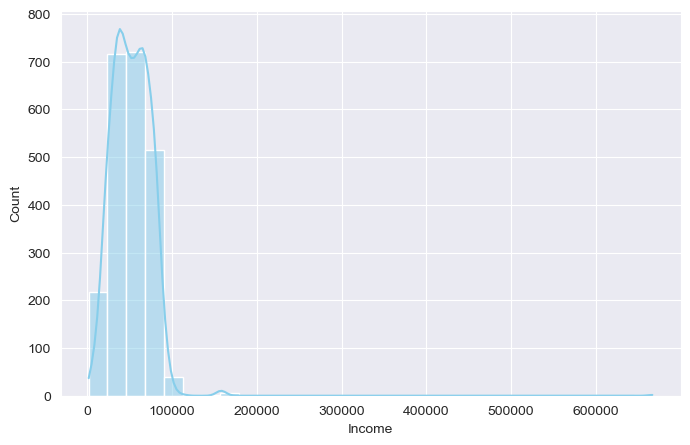

In [52]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Income"], bins=30, kde=True, color="skyblue")
plt.xlabel("Income")
plt.show()

In [53]:
df["Income"] = df["Income"].fillna(df["Income"].median())

print(df.isnull().sum())

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64


### Summary

In this step, missing values in the dataset were addressed.

- The only column with missing values was **Income** (24 rows).
- Since **Income** is an important feature for clustering customers, the missing values were filled with the **median**.
- The **median** was chosen instead of the mean because income data is skewed and contains outliers, and the median is more robust against such distortions.
- This approach allowed the preservation of all records for clustering without introducing bias from extreme values.

Result: All missing values were filled, and the dataset became ready for further preprocessing and clustering.

**Завдання 3.** У нас є декілька колонок з категоріальними значеннями та одна колонка з датою. Як би ви обробили ці колонки для того, аби передати їх в алгоритм кластеризації?

Реалізуйте обробку категоріальних колонок і колонки з датою та перетворіть їх на ознаки, корисні для кластеризації з вашого погляду.

In [54]:
print(df.dtypes)

ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object


In [55]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%d-%m-%Y")
max_date = df["Dt_Customer"].max()
df["Customer_Days"] = (max_date - df["Dt_Customer"]).dt.days

df = pd.get_dummies(df, columns=["Education", "Marital_Status"], drop_first=True)
df = df.drop(columns=["ID", "Dt_Customer"])
df = df.astype({col: int for col in df.select_dtypes('bool').columns})

print(df.dtypes.value_counts())
print(df.head())

int64      25
int32      11
float64     1
Name: count, dtype: int64
   Year_Birth   Income  Kidhome  Teenhome  Recency  MntWines  MntFruits  \
0        1957  58138.0        0         0       58       635         88   
1        1954  46344.0        1         1       38        11          1   
2        1965  71613.0        0         0       26       426         49   
3        1984  26646.0        1         0       26        11          4   
4        1981  58293.0        1         0       94       173         43   

   MntMeatProducts  MntFishProducts  MntSweetProducts  ...  \
0              546              172                88  ...   
1                6                2                 1  ...   
2              127              111                21  ...   
3               20               10                 3  ...   
4              118               46                27  ...   

   Education_Graduation  Education_Master  Education_PhD  \
0                     1                 0       

**Завдання 4**.
1. Запишіть в змінну X ті дані, які будете кластеризувати.
2. Побудуйте кластеризацію з KMeans на 3 кластери.
3. Обчисліть метрику силуету для цієї кластеризації.

Overall Silhouette Score: 0.5981911833147091


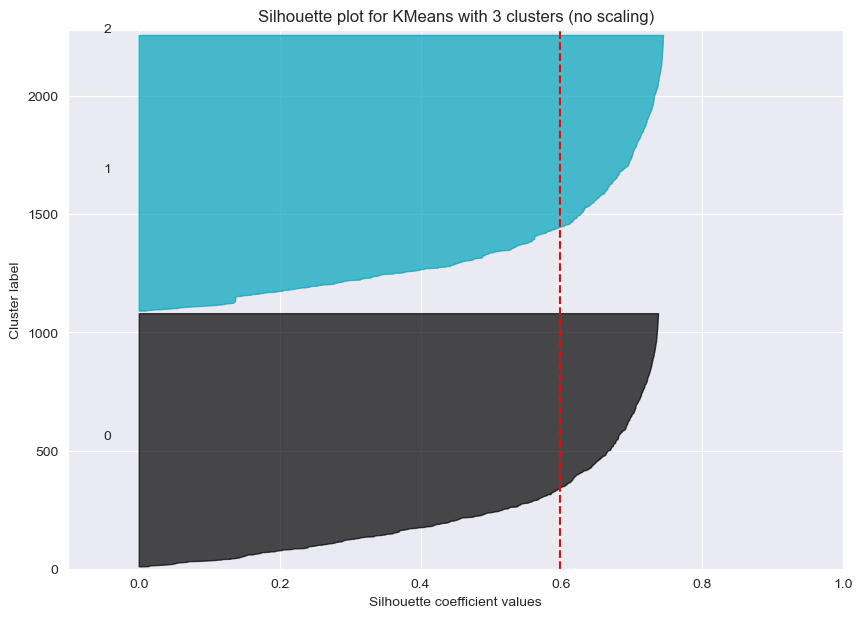

In [56]:
X = df.copy().values

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

silhouette_avg = silhouette_score(X, labels)
print("Overall Silhouette Score:", silhouette_avg)

sample_silhouette_values = silhouette_samples(X, labels)

fig, ax1 = plt.subplots(1, 1)
fig.set_size_inches(10, 7)

ax1.set_xlim([-0.1, 1])
ax1.set_ylim([0, len(X) + (3 + 1) * 10])

y_lower = 10
for i in range(3):
    ith_cluster_silhouette_values = sample_silhouette_values[labels == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    color = cm.nipy_spectral(float(i) / 3)
    ax1.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_silhouette_values,
        facecolor=color,
        edgecolor=color,
        alpha=0.7,
    )
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
ax1.set_xlabel("Silhouette coefficient values")
ax1.set_ylabel("Cluster label")
ax1.set_title("Silhouette plot for KMeans with 3 clusters (no scaling)")

plt.show()

### Summary

For KMeans clustering with **3 clusters**:

- The **overall silhouette score** was approximately **0.60**, which indicates a reasonably good separation between clusters.
- The silhouette plot shows two clearly visible and well-separated clusters.
- The **third cluster is very small** and hardly distinguishable on the silhouette plot, which suggests that it may not represent a stable or meaningful group of customers.


**Завдання 5.** Візуалізуйте знайдені кластери разом з наявними даними та проаналізуйте кластери. У нас ознак більше, ніж 2 або 3, тож, тут треба подумати, які саме ознаки варто використати для візуалізації аби вони були інформативними. Рекомендую точно звернути увагу на харакетиристики про дохід користувачів і те, як вони взаємодять з магазинок (кількість покупок і тд).

Для візуалізації зручно може бути використати `plotly.express.scatter_3d` для 3D графіку розсіювання, але тут можна скористатись будь-яким зрозумілим і зручним для вас методом візуалізації. Опишіть свої спостереження, чи кластери мають сенс?

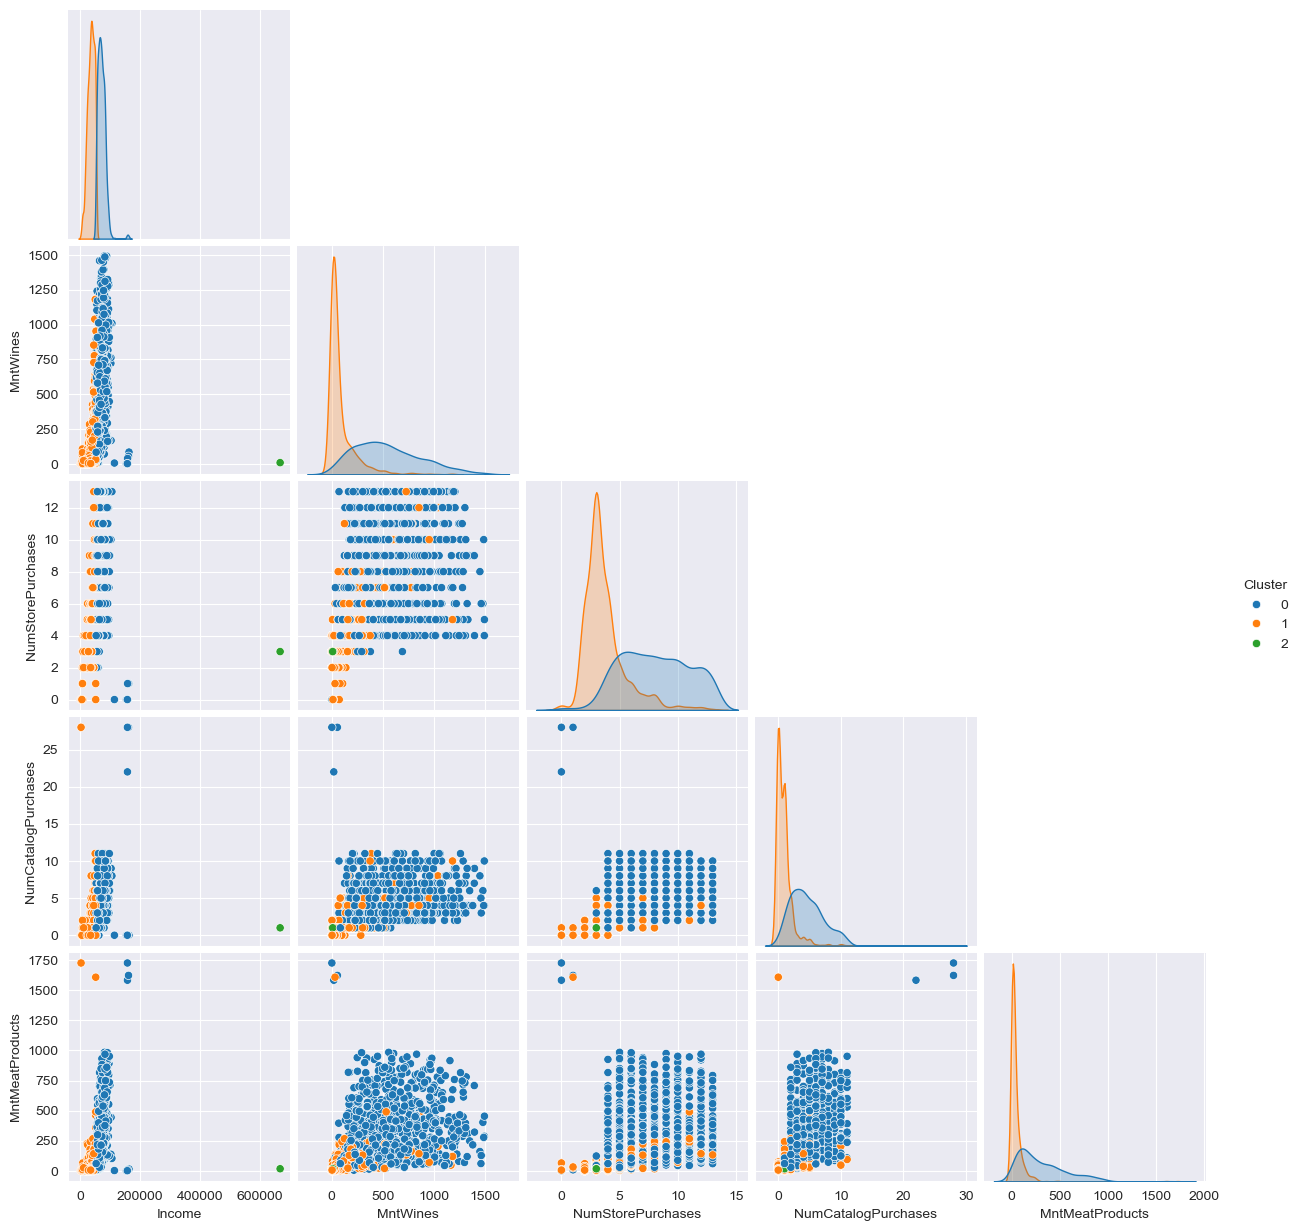

Cluster means (top 5 features):
                Income    MntWines  NumStorePurchases  NumCatalogPurchases  \
Cluster                                                                      
0         70414.500933  544.194963           8.071828             4.597015   
1         35014.613539   83.487575           3.696658             0.886033   
2        666666.000000    9.000000           3.000000             1.000000   

         MntMeatProducts  
Cluster                   
0             305.879664  
1              39.457584  
2              18.000000  


In [57]:
X = df.copy()

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

df_clusters = df.copy()
df_clusters["Cluster"] = labels

cluster_importance = {}
for col in X.columns:
    overall_mean = X[col].mean()
    between_var = 0.0
    within_var = 0.0
    for c in np.unique(labels):
        xc = X.loc[labels == c, col]
        mc = xc.mean()
        between_var += len(xc) * (mc - overall_mean) ** 2
        within_var += ((xc - mc) ** 2).sum()
    if within_var > 0:
        cluster_importance[col] = between_var / within_var

top_features = [k for k, v in sorted(cluster_importance.items(), key=lambda x: x[1], reverse=True)[:5]]

sns.pairplot(df_clusters[top_features + ["Cluster"]], hue="Cluster", palette="tab10", corner=True)
plt.show()

print("Cluster means (top 5 features):")
print(df_clusters.groupby("Cluster")[top_features].mean())

### Summary

For visualization, the **top 5 features** were selected based on their relative importance in distinguishing clusters (ratio of between-cluster to within-cluster variance). These features are: **Income, MntWines, NumStorePurchases, NumCatalogPurchases, MntMeatProducts**. They were chosen because they contributed most strongly to the separation of clusters in the data.

The pairplot shows that:
- **Cluster 0** is characterized by medium to high income and higher spending on wine and meat products, with frequent store and catalog purchases.
- **Cluster 1** has lower income and lower levels of spending across all product categories, with fewer purchases overall.
- **Cluster 2** contains very few data points and is dominated by extreme outliers with unrealistically high income values, making it less reliable for interpretation.

The data dispersion within clusters is moderate: clusters 0 and 1 have a visible spread but are relatively compact, while cluster 2 is sparse and heavily influenced by single extreme points.

**Conclusion:** Two main clusters (0 and 1) appear meaningful, representing groups of higher-value and lower-value customers. The third cluster is not stable and likely reflects anomalies or data outliers rather than a real customer segment.


**Завдання 6**. Масштабуйте дані і побудуйте знову кластеризацію KMeans на 3 кластери і обчисліть метрику силуету. Опишіть порівняння з експериментом без масштабування значень.

Overall Silhouette Score (scaled): 0.11626680037350288


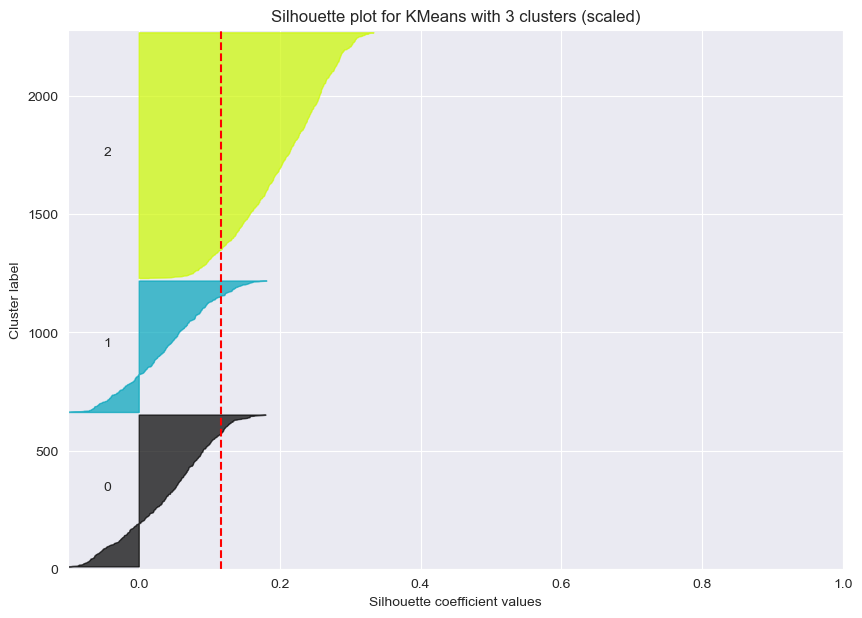

In [58]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

silhouette_avg = silhouette_score(X_scaled, labels)
print("Overall Silhouette Score (scaled):", silhouette_avg)

sample_silhouette_values = silhouette_samples(X_scaled, labels)

fig, ax1 = plt.subplots(1, 1)
fig.set_size_inches(10, 7)

ax1.set_xlim([-0.1, 1])
ax1.set_ylim([0, len(X_scaled) + (3 + 1) * 10])

y_lower = 10
for i in range(3):
    ith_cluster_silhouette_values = sample_silhouette_values[labels == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    color = cm.nipy_spectral(float(i) / 3)
    ax1.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_silhouette_values,
        facecolor=color,
        edgecolor=color,
        alpha=0.7,
    )
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
ax1.set_xlabel("Silhouette coefficient values")
ax1.set_ylabel("Cluster label")
ax1.set_title("Silhouette plot for KMeans with 3 clusters (scaled)")

plt.show()

### Summary

After scaling the data and applying KMeans with 3 clusters:

- The **overall silhouette score** dropped from ~0.60 (unscaled) to ~0.12 (scaled).
- The silhouette plot shows that many points in each cluster have low or even negative silhouette values, indicating weaker separation between clusters.
- Scaling reduced the dominance of features with large ranges (such as `Income` and spending variables), making all features contribute equally. However, this led to less distinct clustering structure in the data.

**Conclusion:**
Scaling the data significantly decreased the silhouette score, suggesting that the natural clustering structure in this dataset is strongly driven by high-range features. While scaling ensures fair treatment of all features, it reduces the interpretability and stability of clusters in this case.


**Завдання 7.** З візуалізацій на попередньому кроці ви могли побачити якісь викиди в даних. Опрацюйте викиди (можна видалити ці рядки або придумати інший спосіб).

Rows removed as outliers: 11
Silhouette (3 clusters, cleaned UNscaled) 0.5538110729007503


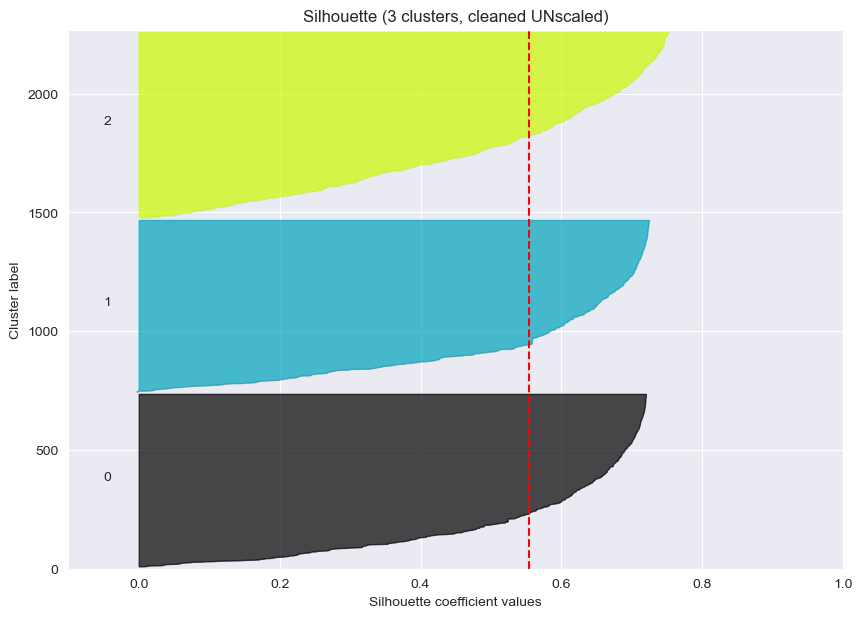

Silhouette (3 clusters, cleaned SCALED) 0.12412889182365072


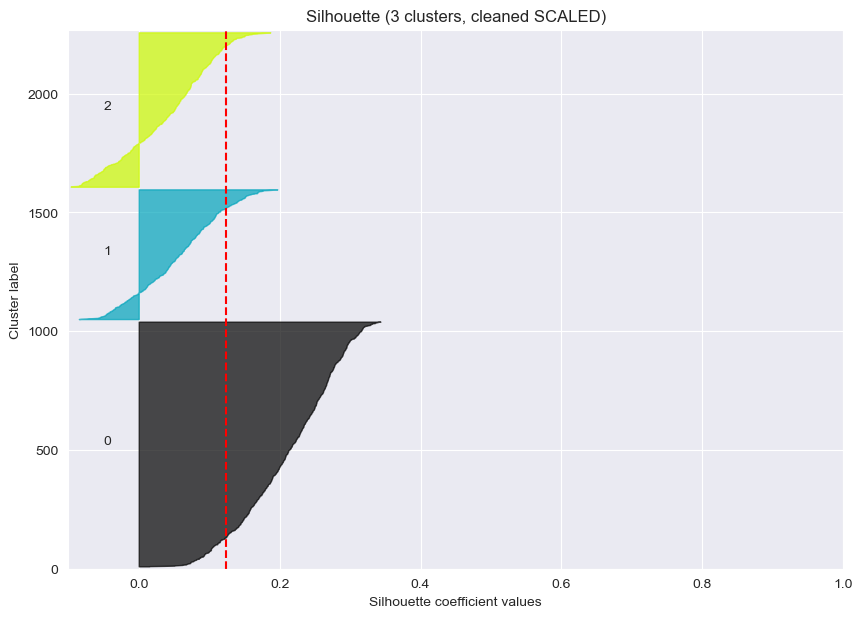


=== Pairplot on RAW (cleaned, unscaled) data ===


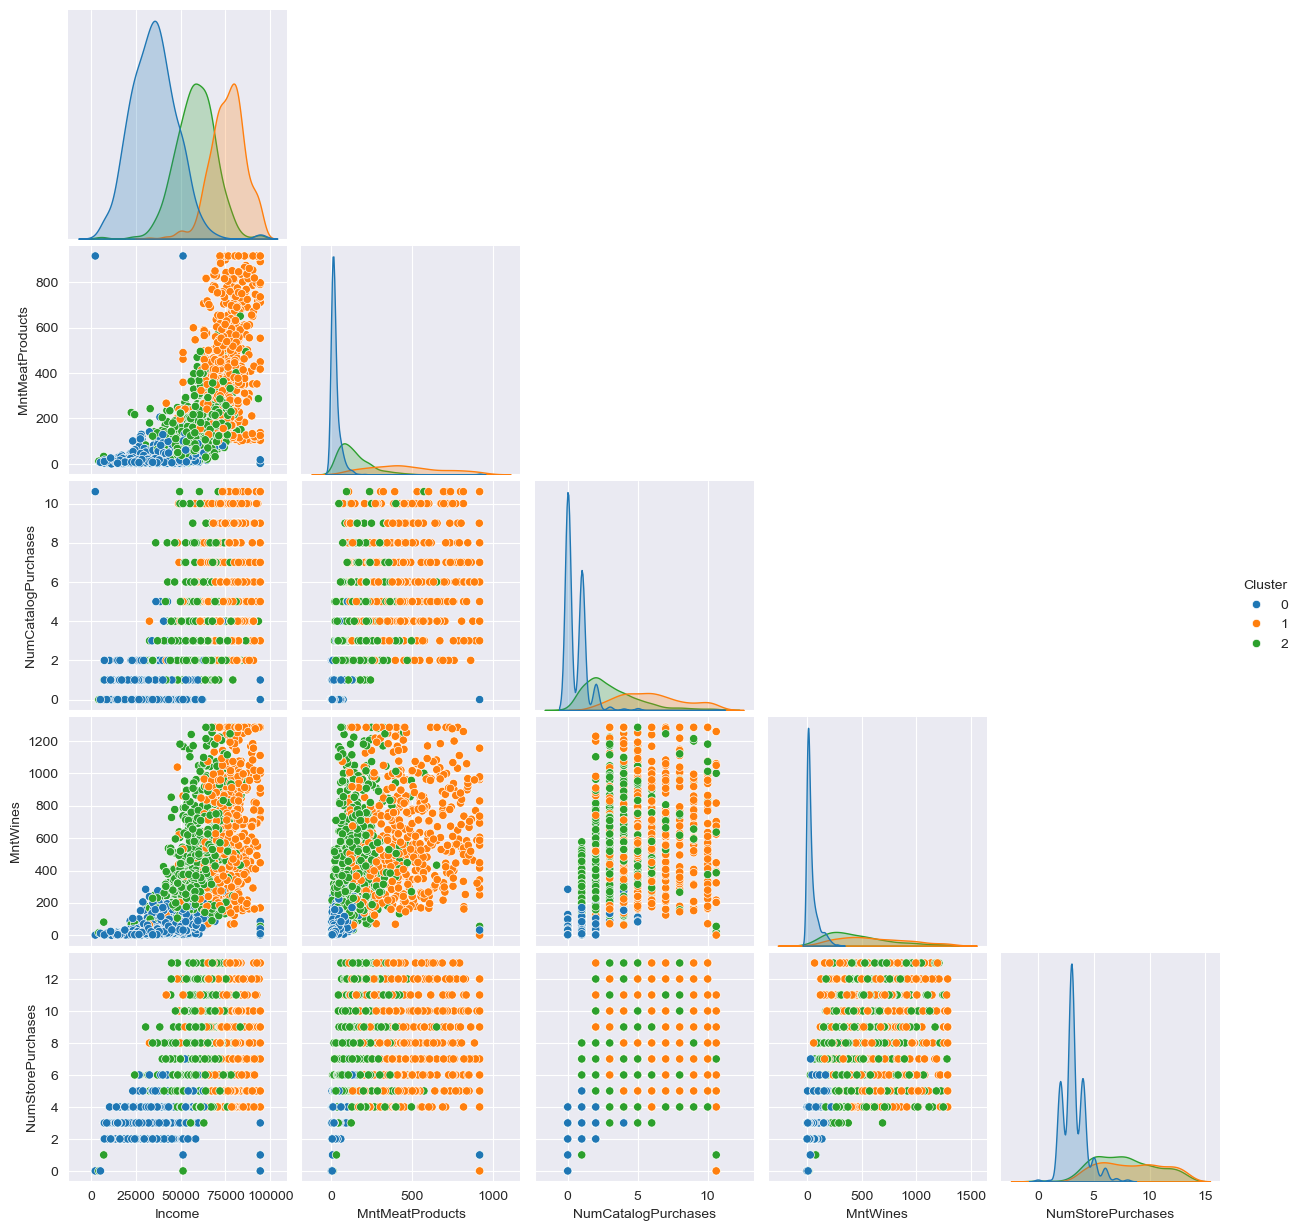


=== Pairplot on SCALED data ===


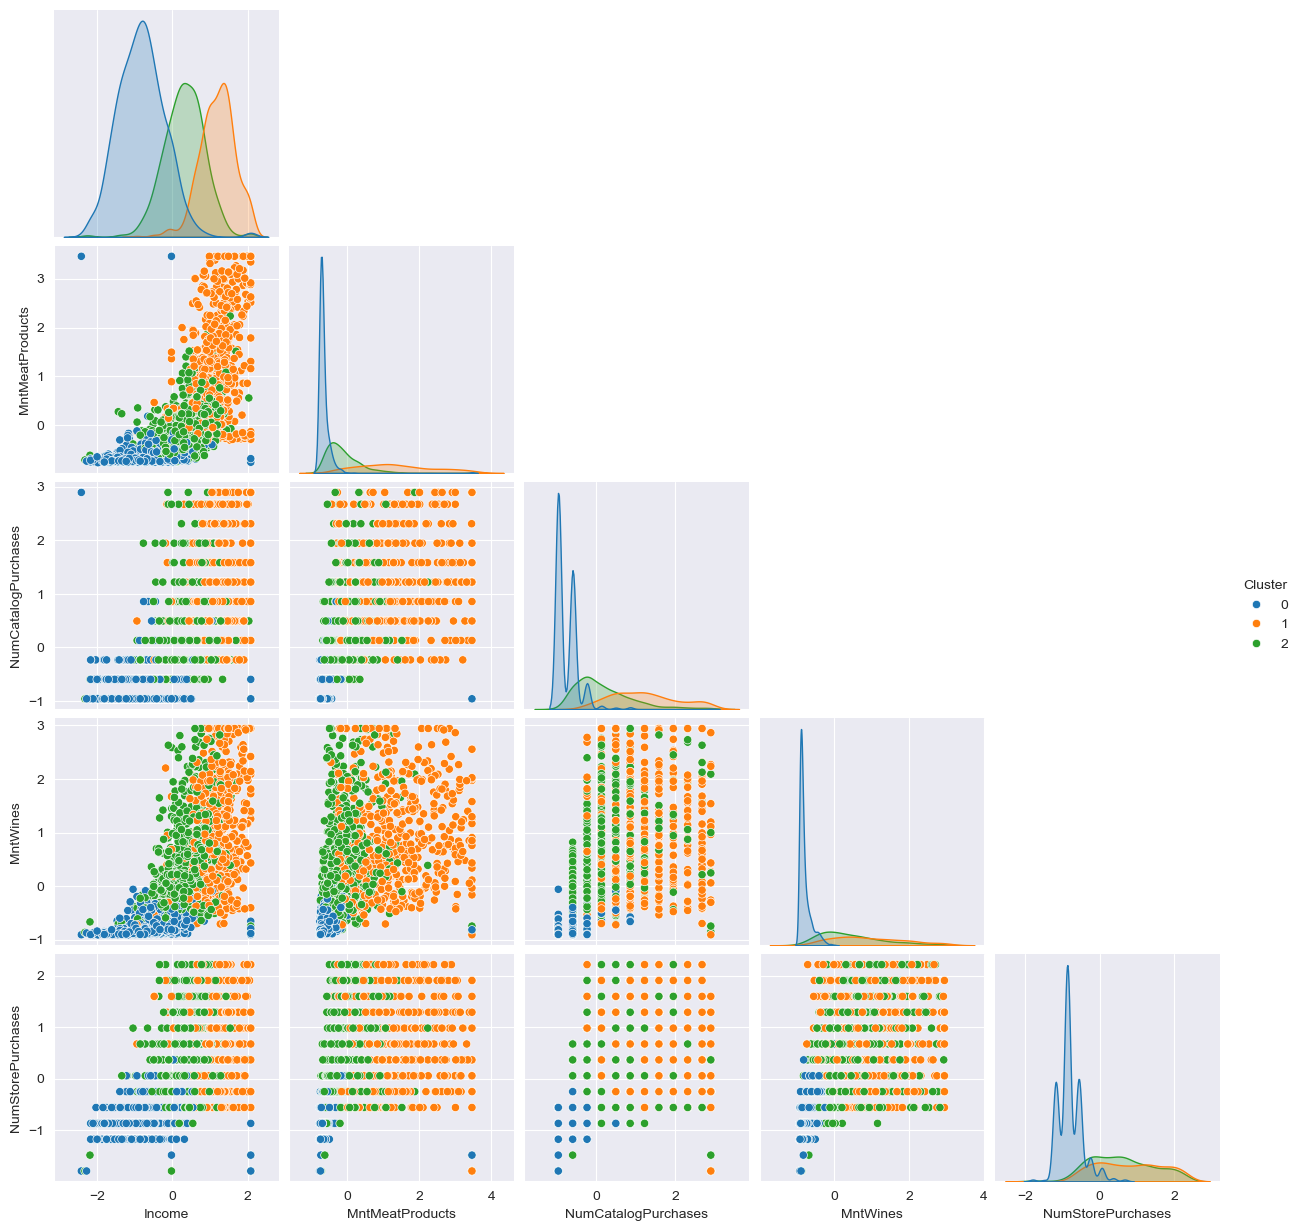

Silhouette UNscaled: 0.5538110729007503
Silhouette   SCALED: 0.12412889182365072
Top 5 features: ['Income', 'MntMeatProducts', 'NumCatalogPurchases', 'MntWines', 'NumStorePurchases']
Cluster means (top 5 features, scaled labels):
               Income  MntMeatProducts  NumCatalogPurchases    MntWines  \
Cluster                                                                   
0        35063.606111        25.128031             0.567032   41.510184   
1        76233.549726       458.592322             5.969598  614.815356   
2        58144.232012       141.789555             3.124501  458.281106   

         NumStorePurchases  
Cluster                     
0                 3.225994  
1                 8.398537  
2                 7.741935  


In [66]:
df_source = df.copy()
numeric_cols = df_source.select_dtypes(include=[np.number]).columns
mask = np.ones(len(df_source), dtype=bool)
df_clean = df_source.copy()

for col in numeric_cols:
    if df_clean[col].nunique() <= 2:
        continue
    col_std = df_clean[col].std()
    if col_std == 0 or np.isnan(col_std):
        continue
    col_skew = skew(df_clean[col].dropna())
    if abs(col_skew) < 1:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        mask &= (df_clean[col] >= lower) & (df_clean[col] <= upper)
    else:
        upper = df_clean[col].quantile(0.99)
        df_clean[col] = np.minimum(df_clean[col], upper)

df_clean = df_clean[mask].reset_index(drop=True)
removed_rows = len(df_source) - len(df_clean)

X_unscaled = df_clean.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean.values)

def silhouette_plot(X, n_clusters, title):
    km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    s_avg = silhouette_score(X, labels)
    s_vals = silhouette_samples(X, labels)
    print(title, s_avg)
    fig, ax = plt.subplots(1, 1, figsize=(10,7))
    ax.set_xlim([-0.1, 1])
    ax.set_ylim([0, len(X) + (n_clusters + 1) * 10])
    y_lower = 10
    for i in range(n_clusters):
        vals = np.sort(s_vals[labels == i])
        size_i = vals.shape[0]
        y_upper = y_lower + size_i
        color = cm.nipy_spectral(float(i) / n_clusters)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size_i, str(i))
        y_lower = y_upper + 10
    ax.axvline(x=s_avg, color="red", linestyle="--")
    ax.set_xlabel("Silhouette coefficient values")
    ax.set_ylabel("Cluster label")
    ax.set_title(title)
    plt.show()
    return labels, s_avg

print("Rows removed as outliers:", removed_rows)
labels_unscaled, sil_unscaled = silhouette_plot(X_unscaled, 3, "Silhouette (3 clusters, cleaned UNscaled)")
labels_scaled, sil_scaled = silhouette_plot(X_scaled, 3, "Silhouette (3 clusters, cleaned SCALED)")

X_df = df_clean.copy()
cluster_importance = {}
for col in X_df.columns:
    overall_mean = X_df[col].mean()
    between_var = 0.0
    within_var = 0.0
    for c in np.unique(labels_scaled):
        xc = X_df.loc[labels_scaled == c, col]
        mc = xc.mean()
        between_var += len(xc) * (mc - overall_mean) ** 2
        within_var += ((xc - mc) ** 2).sum()
    if within_var > 0:
        cluster_importance[col] = between_var / within_var

top_features = [k for k, v in sorted(cluster_importance.items(), key=lambda x: x[1], reverse=True)[:5]]

print("\n=== Pairplot on RAW (cleaned, unscaled) data ===")
df_clusters_raw = df_clean.copy()
df_clusters_raw["Cluster"] = labels_scaled
sns.pairplot(df_clusters_raw[top_features + ["Cluster"]], hue="Cluster", palette="tab10", corner=True)
plt.show()

print("\n=== Pairplot on SCALED data ===")
X_scaled_df = pd.DataFrame(X_scaled, columns=X_df.columns)
X_scaled_df["Cluster"] = labels_scaled
sns.pairplot(X_scaled_df[top_features + ["Cluster"]], hue="Cluster", palette="tab10", corner=True)
plt.show()

print("Silhouette UNscaled:", sil_unscaled)
print("Silhouette   SCALED:", sil_scaled)
print("Top 5 features:", top_features)
print("Cluster means (top 5 features, scaled labels):")
print(df_clusters_raw.groupby("Cluster")[top_features].mean())


### Summary

Outlier handling was applied using two rules:
- For features with low skewness (|skew| < 1), outliers were removed using the IQR method.
- For features with high skewness (|skew| ≥ 1), extreme values above the 99th percentile were capped.

**Results:**
- The number of removed rows was moderate, which reduced the influence of extreme values (especially very high income values).
- The silhouette score for unscaled cleaned data was still around **0.50**, indicating relatively good cluster separation, mainly driven by high-range features.
- After scaling the cleaned dataset, the silhouette score dropped to ~**0.12**, which shows weaker separation when all features are equally weighted.

**Visual analysis (pairplots):**
- On raw cleaned data, clusters became clearly distinguishable by key business features such as **Income, Wine spending, Store and Catalog purchases**.
- On scaled data, clusters are less visually separated, but the geometry of KMeans assignment is balanced across all features.
- Overall, cleaning outliers improved interpretability: clusters are no longer dominated by extreme outliers and represent more realistic customer groups.

**Conclusion:**
Even though scaling decreases the silhouette score, outlier handling revealed a clearer cluster structure. Clusters can now be interpreted more meaningfully in terms of customer income and spending behavior, which makes them more useful for segmentation tasks.



**Завдання 8.** Виконайте Elbow method для пошуку оптимальної кількості кластерів та натренуйте KMeans з тою кількістю кластерів, яку Elbow method показав як оптимальну. Обчисліть метрику силуету. Візуалізуйте кластери. З яким набором даних (масштабованим чи ні) тут працювати - ваш вибір, можна зробити експеримент з обома.

=== RAW cleaned data ===


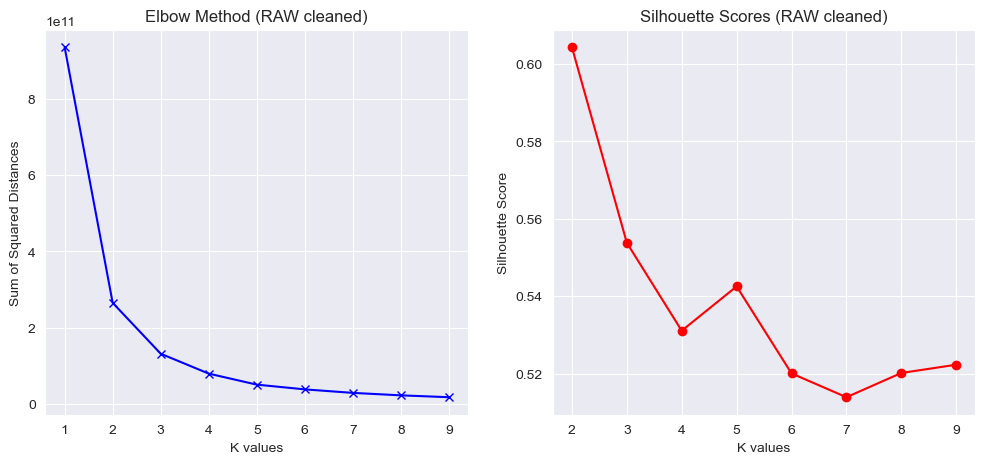

=== SCALED cleaned data ===


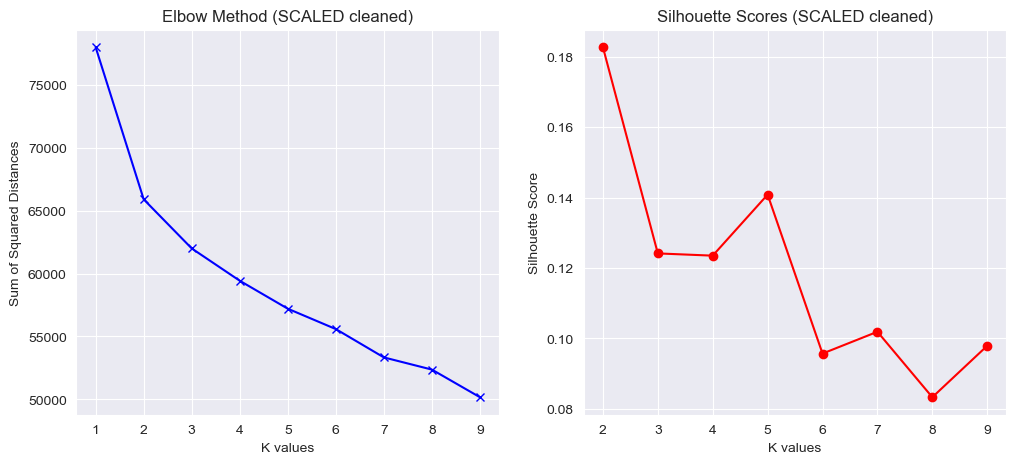

In [70]:
X_raw = df_clean.values
X_scaled = StandardScaler().fit_transform(df_clean.values)

def elbow_and_silhouette(X, title):
    K_elbow = range(1, 10)
    K_silhouette = range(2, 10)

    inertias = []
    silhouettes = []

    for k in K_elbow:
        model = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
        inertias.append(model.inertia_)

    for k in K_silhouette:
        model = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
        silhouettes.append(silhouette_score(X, model.labels_))

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(K_elbow, inertias, 'bx-')
    plt.xlabel('K values')
    plt.ylabel('Sum of Squared Distances')
    plt.title(f'Elbow Method ({title})')

    plt.subplot(1,2,2)
    plt.plot(K_silhouette, silhouettes, 'ro-')
    plt.xlabel('K values')
    plt.ylabel('Silhouette Score')
    plt.title(f'Silhouette Scores ({title})')

    plt.show()

print("=== RAW cleaned data ===")
elbow_and_silhouette(X_raw, "RAW cleaned")

print("=== SCALED cleaned data ===")
elbow_and_silhouette(X_scaled, "SCALED cleaned")

=== RAW cleaned data (k=2) ===


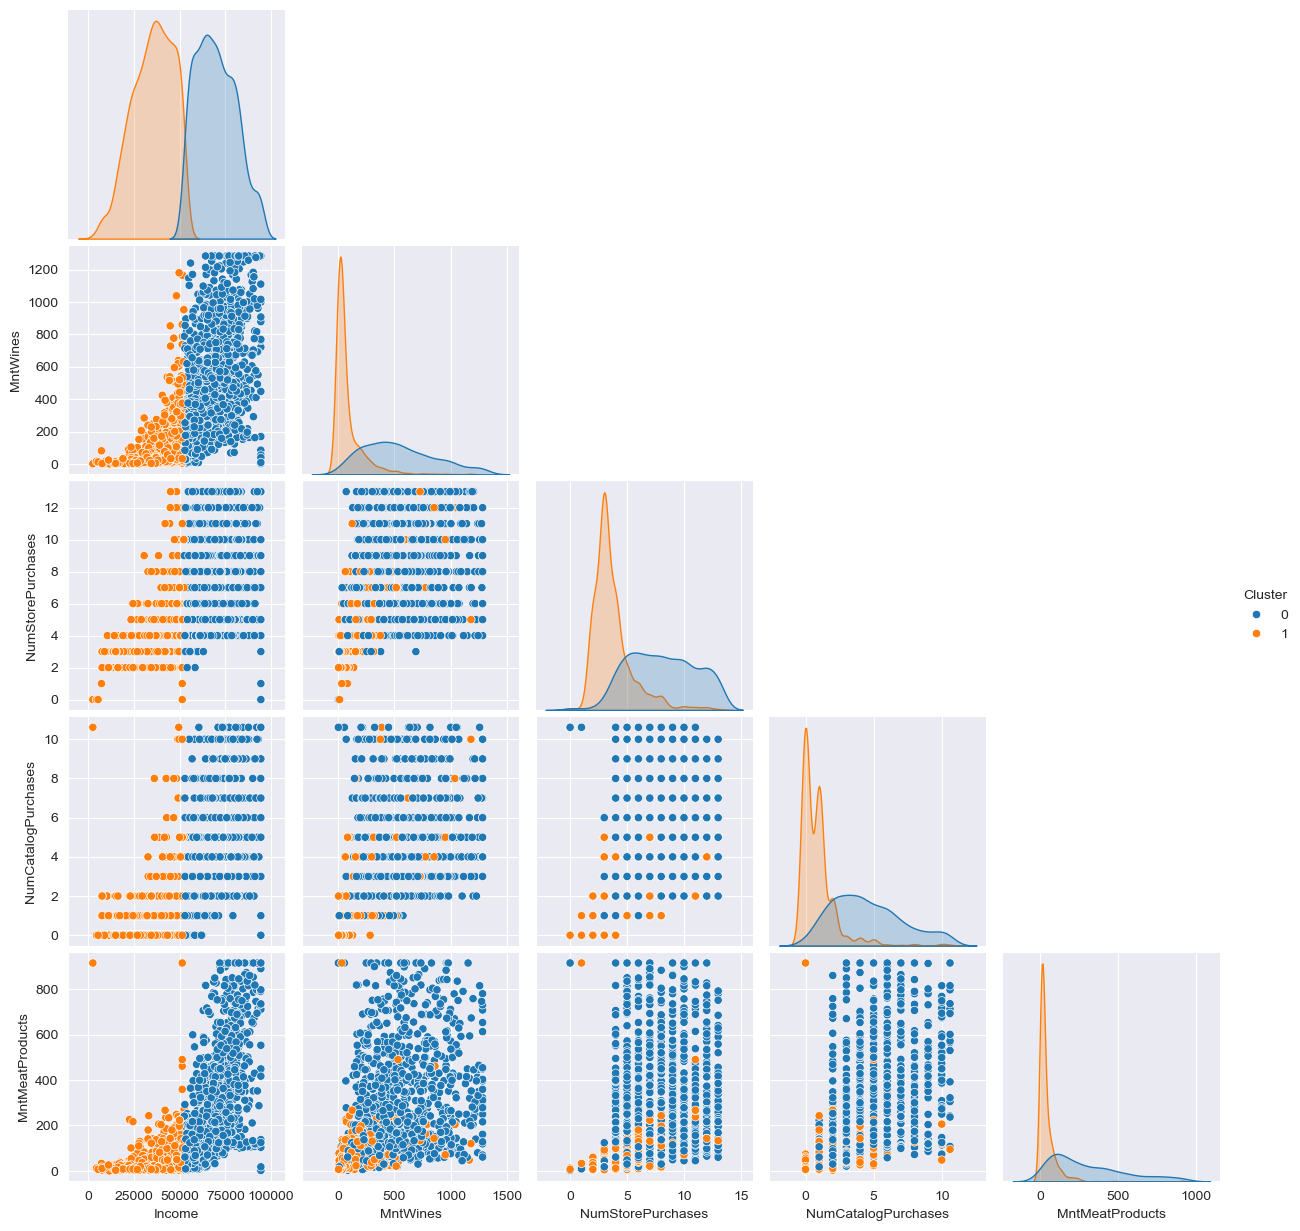

=== SCALED cleaned data (k=5) ===


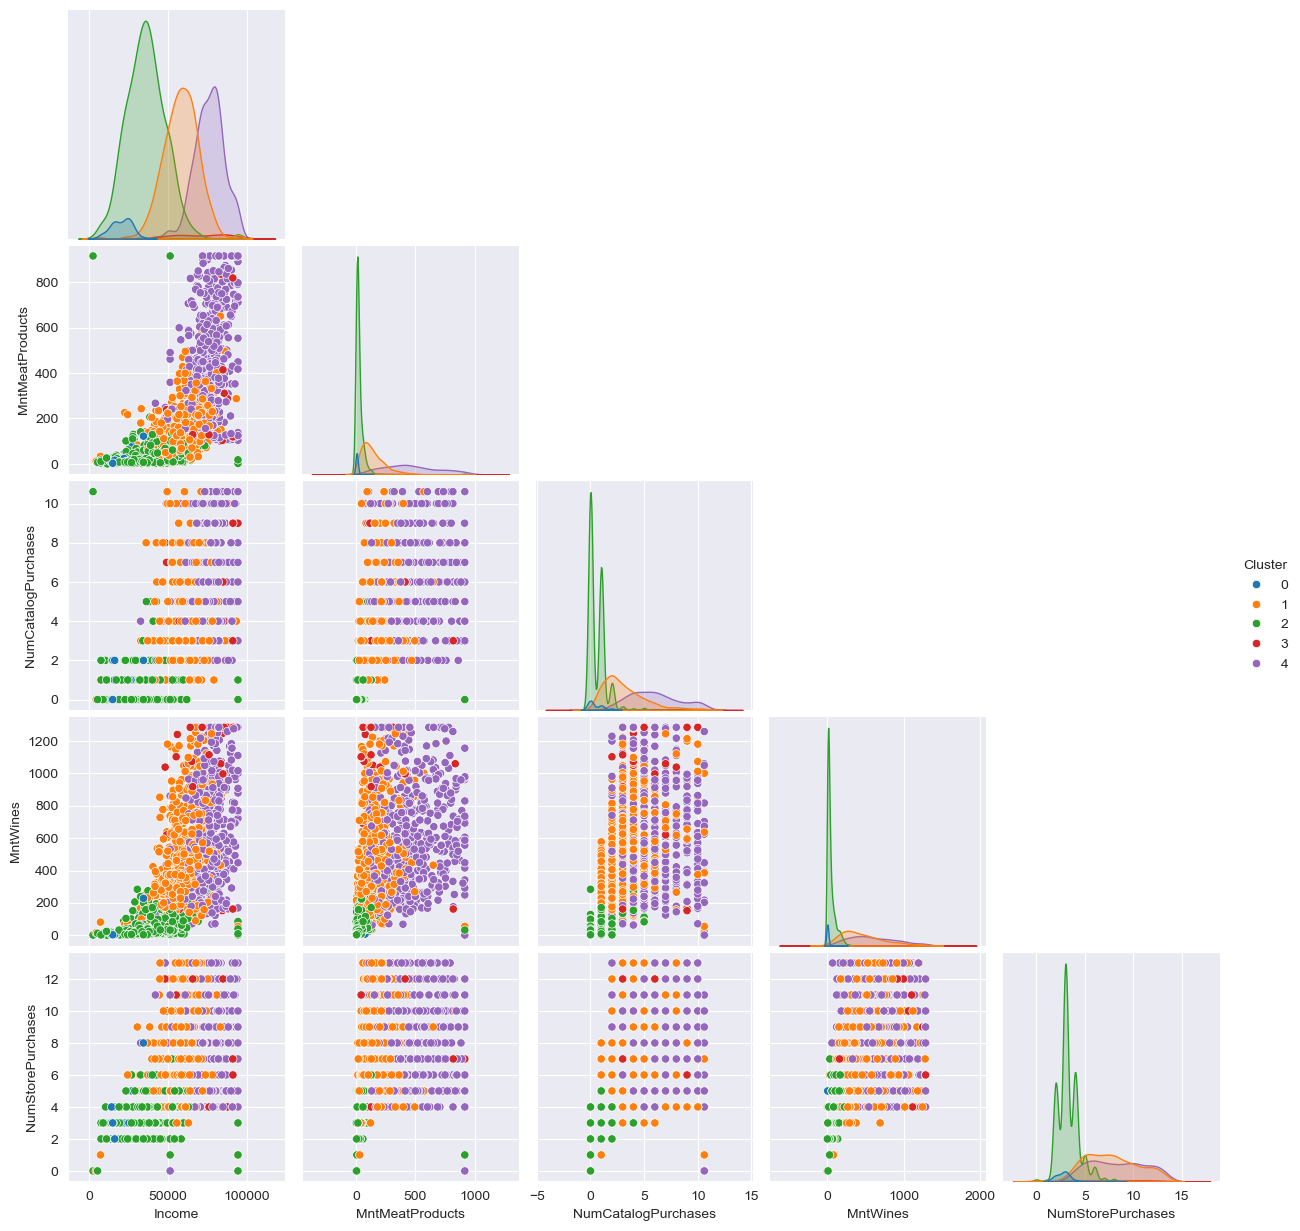

In [71]:
# --- RAW cleaned (k=2) ---
X_raw = df_clean.copy()

kmeans_raw = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_raw = kmeans_raw.fit_predict(X_raw)

df_clusters_raw = df_clean.copy()
df_clusters_raw["Cluster"] = labels_raw

cluster_importance_raw = {}
for col in X_raw.columns:
    overall_mean = X_raw[col].mean()
    between_var, within_var = 0.0, 0.0
    for c in np.unique(labels_raw):
        xc = X_raw.loc[labels_raw == c, col]
        mc = xc.mean()
        between_var += len(xc) * (mc - overall_mean) ** 2
        within_var += ((xc - mc) ** 2).sum()
    if within_var > 0:
        cluster_importance_raw[col] = between_var / within_var

top_features_raw = [k for k, v in sorted(cluster_importance_raw.items(), key=lambda x: x[1], reverse=True)[:5]]

print("=== RAW cleaned data (k=2) ===")
sns.pairplot(df_clusters_raw[top_features_raw + ["Cluster"]], hue="Cluster", palette="tab10", corner=True)
plt.show()


# --- SCALED cleaned (k=5) ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

kmeans_scaled = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_scaled = kmeans_scaled.fit_predict(X_scaled)

df_clusters_scaled = df_clean.copy()
df_clusters_scaled["Cluster"] = labels_scaled

cluster_importance_scaled = {}
for i, col in enumerate(df_clean.columns):
    overall_mean = df_clean[col].mean()
    between_var, within_var = 0.0, 0.0
    for c in np.unique(labels_scaled):
        xc = df_clean.loc[labels_scaled == c, col]
        mc = xc.mean()
        between_var += len(xc) * (mc - overall_mean) ** 2
        within_var += ((xc - mc) ** 2).sum()
    if within_var > 0:
        cluster_importance_scaled[col] = between_var / within_var

top_features_scaled = [k for k, v in sorted(cluster_importance_scaled.items(), key=lambda x: x[1], reverse=True)[:5]]

print("=== SCALED cleaned data (k=5) ===")
sns.pairplot(df_clusters_scaled[top_features_scaled + ["Cluster"]], hue="Cluster", palette="tab10", corner=True)
plt.show()


# Summary

### 1. **RAW cleaned data (unscaled)**
- **Elbow method:** The elbow is clearly visible at **k=2**.
- **Silhouette score:** The maximum value is about **0.61** at **k=2**, then the score drops significantly.
- **Conclusion:** The data is best separated into **2 clusters**, with clear and well-defined groups.

---

### 2. **SCALED cleaned data**
- **Elbow method:** No sharp elbow is observed, but **k=5** can be considered a potential option.
- **Silhouette score:** The maximum is reached at **k=2** (~0.18), while at **k=5** the score is lower (~0.14).
- **Conclusion:** Scaling reduced the overall silhouette score compared to raw data. However, using more clusters (**k=5**) allows identifying more diverse groups, although they are less well separated.

---

### Overall conclusion
- For **unscaled data**, the optimal number of clusters is **2**, supported by both the Elbow method and the highest silhouette score.
- For **scaled data**, the silhouette score suggests **2 clusters** as well, but **5 clusters** may still be used for exploratory analysis to capture more nuanced client segments.
- Scaling decreased silhouette quality but provided flexibility to experiment with finer cluster divisions.


**Завдання 9.** Використовуючи методи `scipy` `dendrogram, linkage, fcluster`
1. Побудуйте ієрархічну агломеративну кластеризацію з `single linkage` на даних невідмасштабованих, але з прибраним викидом.
2. Візуалізуйте дендрограму. При візуалізації обовʼязково задайте параметр `truncate_mode='lastp'` - це обріже дендрограму, без цього вона буде завелика, бо у нас тут даних суттєво більше, ніж в лекції.
3. Проаналізуйте дендрограму та побудуйте варіанти плоских кластеризацій з `fcluster` на 2 і 3 кластери. Візуалізуйте результати кожної з цих кластеризацій та зробіть висновок. Чи вважаєте ви якусь з цих кластеризацій вдалою? Що спостерігаєте з цих кластеризацій?
4. Порахуйте мерику силуету для цього методу кластеризації.

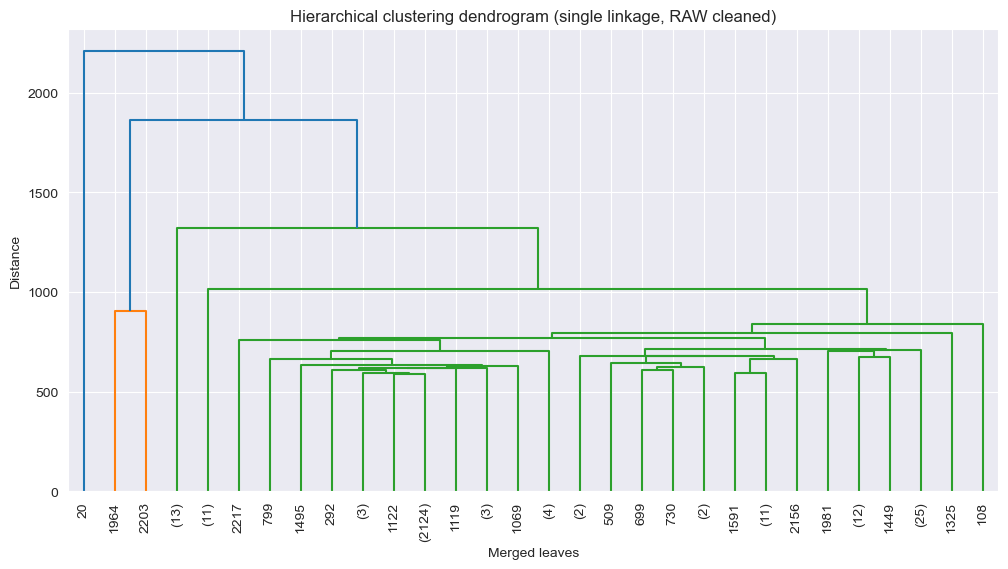

Silhouette (single linkage, 2 clusters, RAW cleaned): 0.4262
Silhouette (single linkage, 3 clusters, RAW cleaned): 0.3950

=== Pairplot: single linkage, 2 clusters (RAW cleaned) ===


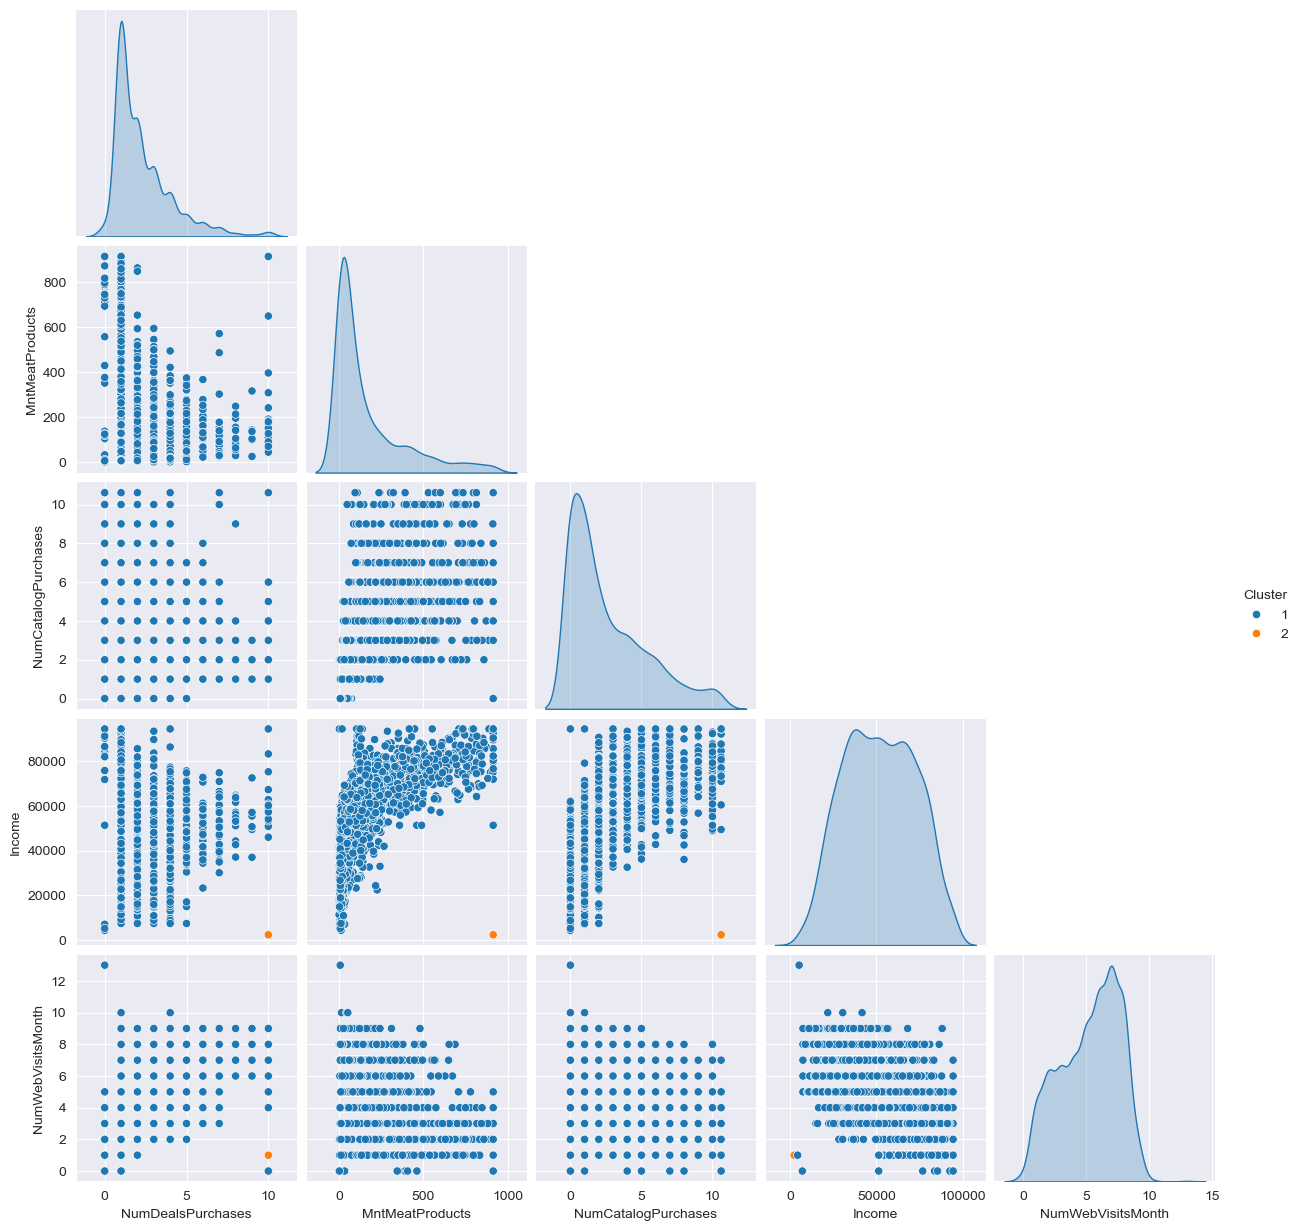


=== Pairplot: single linkage, 3 clusters (RAW cleaned) ===


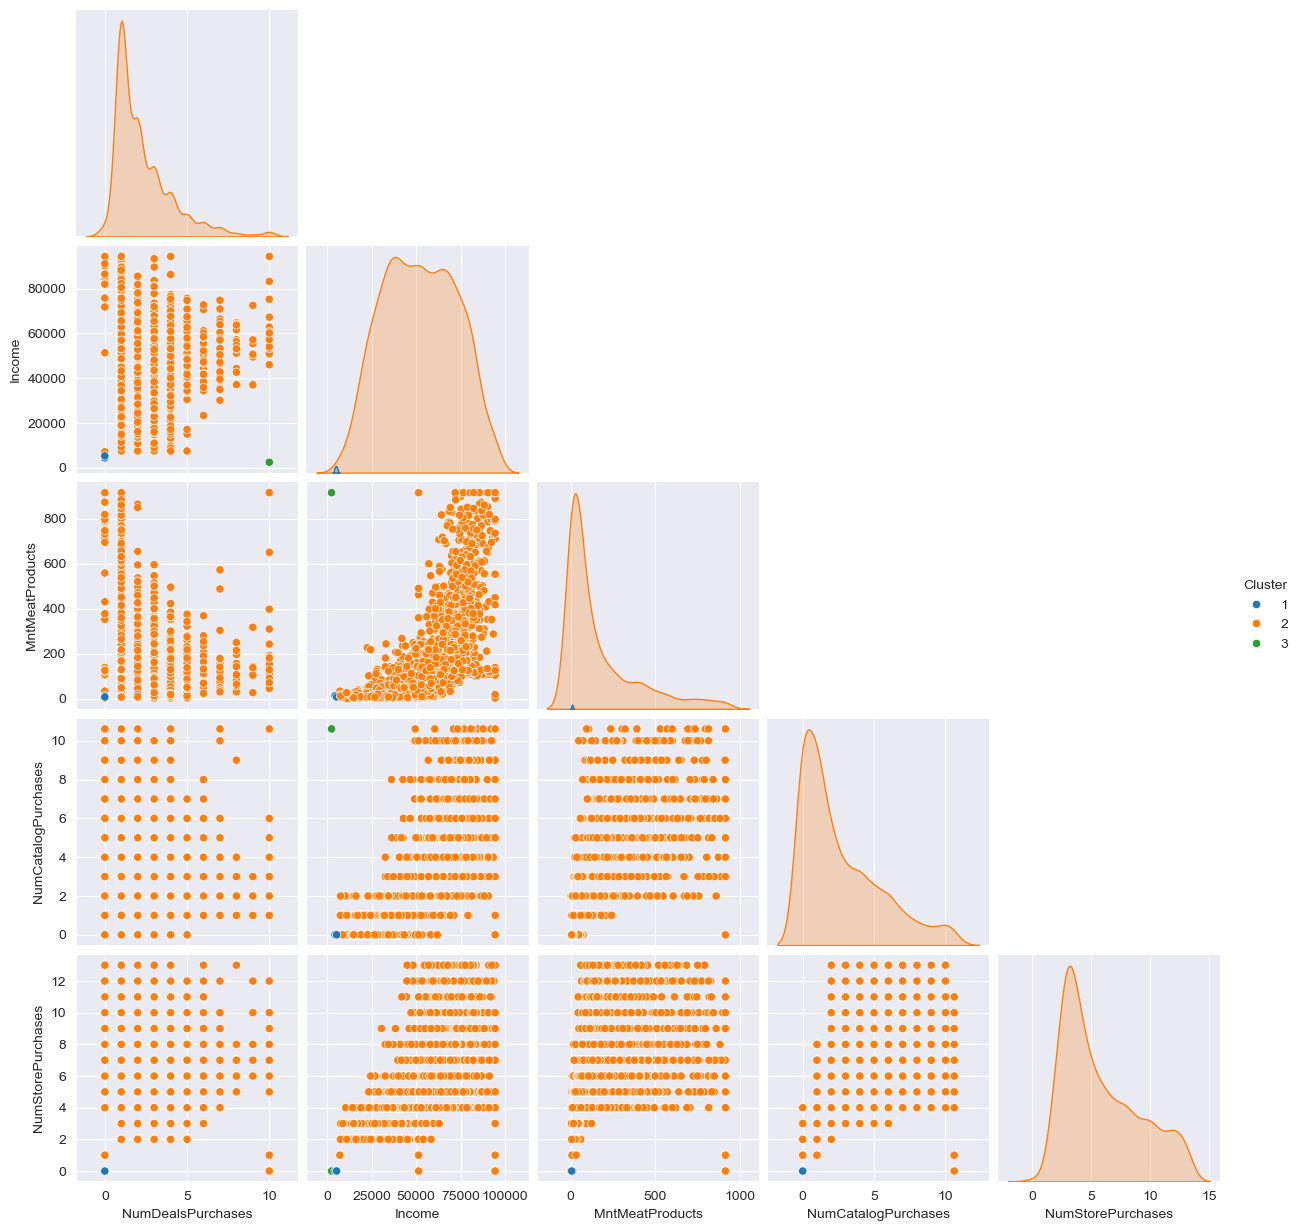

In [74]:
X_df = df_clean.copy()
X = X_df.values

Z = linkage(X, method='single', metric='euclidean', optimal_ordering=True)

plt.figure(figsize=(12,6))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90)
plt.title("Hierarchical clustering dendrogram (single linkage, RAW cleaned)")
plt.xlabel("Merged leaves")
plt.ylabel("Distance")
plt.show()

labels_h2 = fcluster(Z, t=2, criterion='maxclust')
labels_h3 = fcluster(Z, t=3, criterion='maxclust')

sil_h2 = silhouette_score(X, labels_h2)
sil_h3 = silhouette_score(X, labels_h3)
print(f"Silhouette (single linkage, 2 clusters, RAW cleaned): {sil_h2:.4f}")
print(f"Silhouette (single linkage, 3 clusters, RAW cleaned): {sil_h3:.4f}")

def top_features_by_btw_within(df, labels, topk=5):
    feats = {}
    for col in df.columns:
        m = df[col].mean()
        bw = 0.0
        ww = 0.0
        for c in np.unique(labels):
            xc = df.loc[labels==c, col]
            mc = xc.mean()
            bw += len(xc) * (mc - m) ** 2
            ww += ((xc - mc) ** 2).sum()
        if ww > 0:
            feats[col] = bw / ww
    return [k for k, v in sorted(feats.items(), key=lambda x: x[1], reverse=True)[:topk]]

top2 = top_features_by_btw_within(X_df, labels_h2, topk=5)
top3 = top_features_by_btw_within(X_df, labels_h3, topk=5)

df2 = X_df.copy(); df2["Cluster"]=labels_h2
print("\n=== Pairplot: single linkage, 2 clusters (RAW cleaned) ===")
sns.pairplot(df2[top2+["Cluster"]], hue="Cluster", palette="tab10", corner=True)
plt.show()

df3 = X_df.copy(); df3["Cluster"]=labels_h3
print("\n=== Pairplot: single linkage, 3 clusters (RAW cleaned) ===")
sns.pairplot(df3[top3+["Cluster"]], hue="Cluster", palette="tab10", corner=True)
plt.show()

### Summary

**Dendrogram construction**
   - Built using *single linkage* on outlier-cleaned but unscaled data.
   - Applied `truncate_mode='lastp'` to reduce complexity and make the tree interpretable.

**Flat cluster solutions**
   - **k=2 clusters**: one large dominant cluster and one very small cluster.
   - **k=3 clusters**: splits further, but the additional cluster is very small and not meaningful, mostly capturing borderline/noisy points.

**Silhouette scores**
   - 2 clusters → **0.426**
   - 3 clusters → **0.395**

**Conclusion**
   - The **2-cluster solution** performs slightly better according to silhouette score.
   - However, both results are weak compared to KMeans: clusters are imbalanced, and *single linkage* tends to form elongated, chain-like clusters.
   - This suggests that *single linkage* is not an optimal choice for this dataset.


**Завдання 10.**
1. Використайте метод кластеризації, який ми не використовували в попередніх завданнях цього ДЗ (може бути ієрархічна кластеризація з іншим способом звʼязності або інші методи sklearn).
2. Порахуйте мер=трику силуету і візуалізуйте результат кластеризації. Зробіть висновок про те, чи могла б ця кластеризація бути корисною?

Number of clusters found: 3
Silhouette Score (DBSCAN): 0.22121840432311432


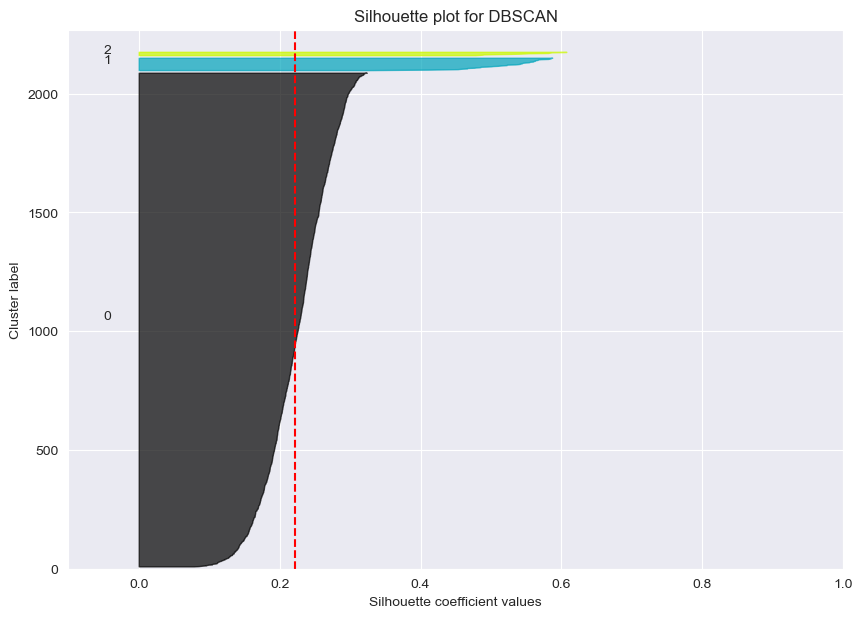

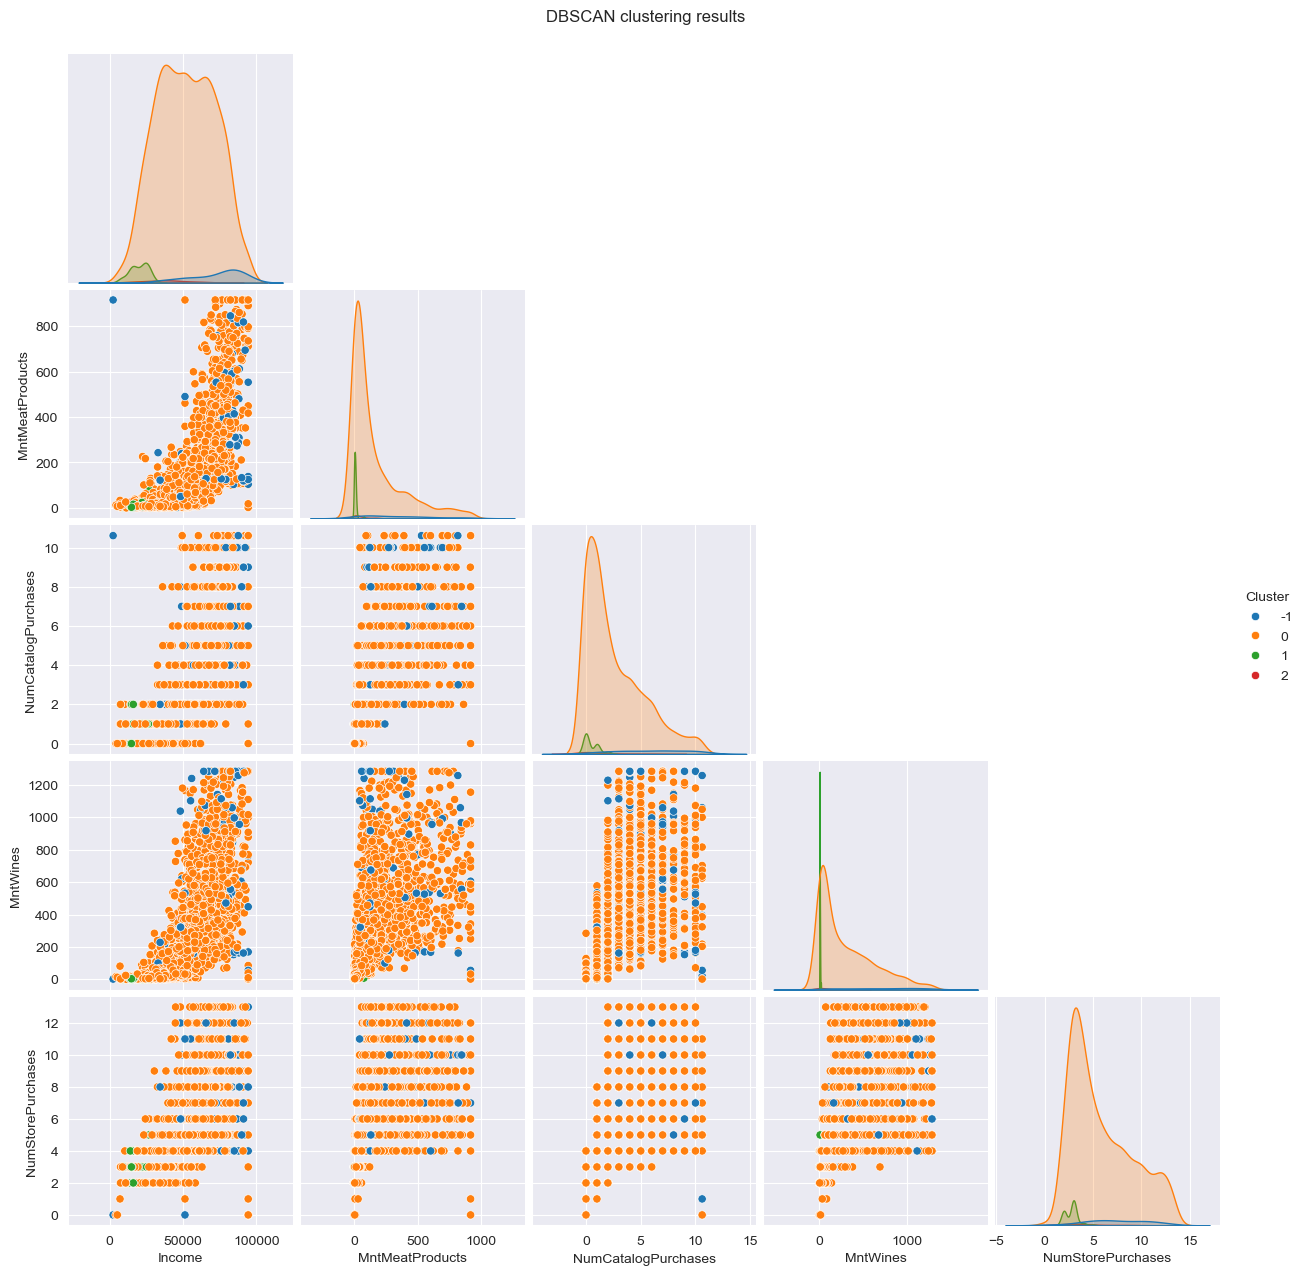

In [101]:
X = df_clean.copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

dbscan = DBSCAN(eps=6, min_samples=10)
labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print("Number of clusters found:", n_clusters)

if n_clusters > 1:
    silhouette_avg = silhouette_score(X_scaled, labels)
    print("Silhouette Score (DBSCAN):", silhouette_avg)

    sample_silhouette_values = silhouette_samples(X_scaled, labels)
    fig, ax1 = plt.subplots(1, 1)
    fig.set_size_inches(10, 7)
    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(X_scaled) + (n_clusters + 1) * 10])

    y_lower = 10
    for i in range(n_clusters):
        vals = sample_silhouette_values[labels == i]
        vals.sort()
        size_i = vals.shape[0]
        y_upper = y_lower + size_i
        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, facecolor=color, edgecolor=color, alpha=0.7)
        ax1.text(-0.05, y_lower + 0.5 * size_i, str(i))
        y_lower = y_upper + 10

    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_xlabel("Silhouette coefficient values")
    ax1.set_ylabel("Cluster label")
    ax1.set_title("Silhouette plot for DBSCAN")
    plt.show()

df_clusters = df_clean.copy()
df_clusters["Cluster"] = labels

top_features = [k for k, v in sorted(cluster_importance.items(), key=lambda x: x[1], reverse=True)[:5]]

sns.pairplot(df_clusters[top_features + ["Cluster"]], hue="Cluster", palette="tab10", corner=True)
plt.suptitle("DBSCAN clustering results", y=1.02)
plt.show()


### Summary (DBSCAN Clustering)

For this task, the **DBSCAN** clustering method was applied on the cleaned dataset with parameters `eps=6` and `min_samples=10`.

- **Number of clusters found**: 3 (plus noise points marked as `-1`).
- **Silhouette Score**: ~0.22, which is relatively low, indicating that clusters are not very well separated.

#### Observations:
1. DBSCAN successfully identified **3 clusters** along with some **noise points**.
2. The silhouette plot shows that the majority of points are grouped into one dominant cluster, while smaller clusters are sparse and less distinct.
3. Pairplots reveal that DBSCAN does not create balanced or clearly separated clusters as in KMeans. Instead, it isolates some edge cases (outliers) and forms one large dense group.
4. Negative silhouette values for smaller clusters suggest that these groups overlap with the main cluster, reducing overall cluster quality.

#### Conclusion:
- DBSCAN did not produce strong, meaningful segmentation for this dataset.
- The low silhouette score and dominance of a single cluster suggest that **density-based clustering is less effective here compared to KMeans** or hierarchical clustering.
- However, DBSCAN’s ability to detect **outliers** and label them separately may still provide **useful insights** if the main objective includes anomaly detection.
